# Project Milestone Two: Modeling and Feature Engineering

### Overview

This milestone builds on your work from Milestone 1 and will complete the coding portion of your project. You will:

1. Pick 3 modeling algorithms from those we have studied.
2. Evaluate baseline models using default settings.
3. Engineer new features and re-evaluate models.
4. Use feature selection techniques and re-evaluate.
5. Fine-tune for optimal performance.
6. Select your best model and report on your results. 

You must do all work in this notebook and upload to your team leader's account in Gradescope. There is no
Individual Assessment for this Milestone. 


In [5]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Prelude: Load your Preprocessed Dataset from Milestone 1

In Milestone 1, you handled missing values, encoded categorical features, and explored your data. Before you begin this milestone, you’ll need to load that cleaned dataset and prepare it for modeling. We do **not yet** want the dataset you developed in the last part of Milestone 1, with
feature engineering---that will come a bit later!

Here’s what to do:

1. Return to your Milestone 1 notebook and rerun your code through Part 3, where your dataset was fully cleaned (assume it’s called `df_cleaned`).

2. **Save** the cleaned dataset to a file by running:

>   df_cleaned.to_csv("zillow_cleaned.csv", index=False)

3. Switch to this notebook and **load** the saved data:

>   df = pd.read_csv("zillow_cleaned.csv")

4. Create a **train/test split** using `train_test_split`.  
   
6. **Standardize** the features (but not the target!) using **only the training data.** This ensures consistency across models without introducing data leakage from the test set:

>   scaler = StandardScaler()   
>   X_train_scaled = scaler.fit_transform(X_train)    
  
**Notes:** 

- You will have to redo the scaling step if you introduce new features (which have to be scaled as well).


In [6]:
#Loading the cleaned Zillow dataset
df = pd.read_csv("zillow_cleaned.csv")

In [7]:
#Creating a train/test split
X = df.drop(columns="taxvaluedollarcnt") 
y = df["taxvaluedollarcnt"] 
test_size = 0.2 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = test_size, random_state=random_state)

In [8]:
#Using scaler to standardize the features (excluding the target) with the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

### Part 1: Picking Three Models and Establishing Baselines [6 pts]

Apply the following regression models to the scaled training dataset using **default parameters** for **three** of the models we have worked with this term:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Bagging
- Random Forest
- Gradient Boosting Trees

For each of the three models:
- Use **repeated cross-validation** (e.g., 5 folds, 5 repeats).
- Report the **mean and standard deviation of CV MAE Score**. 


In [9]:
#Defining the function for our linear regression model
def run_linear_regression(X_train_scaled, y_train, X_test_scaled, y_test,
                          cv_splits=5,
                          cv_repeats=5,
                          n_jobs = -1):
   
    #Defining the model
    lr_model = LinearRegression()

    #Performing cross valifdation and computing cross-validated MAE
    cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)
    neg_cv_scores_linear = cross_val_score(lr_model, X_train_scaled, y_train,
                                cv=cv,
                                scoring='neg_mean_absolute_error',
                                n_jobs = -1)
    
    cv_scores_linear = -neg_cv_scores_linear
    
    mean_cv_mae_linear = np.mean(cv_scores_linear)
    std_cv_mae_linear = np.std(cv_scores_linear)

    #Fitting the model on the training data
    lr_model.fit(X_train_scaled, y_train)
    
    return mean_cv_mae_linear, std_cv_mae_linear, lr_model

In [10]:
#Running the linear regression model
mean_cv_mae_linear, std_cv_mae_linear, lr_model = run_linear_regression(X_train_scaled, y_train, 
                                                                        X_test_scaled, y_test)

#Printing the results
print("Linear Regression:\n")
print(f"Mean CV MAE: {mean_cv_mae_linear:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_linear:.4f}\n")

Linear Regression:

Mean CV MAE: 186977.0278
Standard Deviation of CV MAE: 1149.2885



In [11]:
#Defining the feature names for optional later visualization
feature_names = list(X_train.columns)

#Defining the function for our decision tree model
def run_decision_tree_regressor(X_train_scaled,
                                y_train,
                                max_depth=None,          
                                max_features=None,       
                                min_samples_split=2,
                                min_samples_leaf=1,
                                max_leaf_nodes=None,
                                criterion='absolute_error',
                                ccp_alpha=0.0,
                                cv_splits=5,
                                cv_repeats=5,
                                random_state=random_state,                          
                                n_jobs=-1,              
                                visualize=False
                               ):
    
    #Initializing the model
    dt_model = DecisionTreeRegressor(
        max_depth=max_depth,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_leaf_nodes=max_leaf_nodes,
        criterion=criterion,
        ccp_alpha=ccp_alpha,
        random_state=random_state)
    
    #Performing cross validation and computing cross-validated MAE
    cv = RepeatedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
    neg_cv_scores_dt = cross_val_score(dt_model, X_train_scaled, y_train,
                                cv=cv,
                                scoring='neg_mean_absolute_error',
                                n_jobs=n_jobs)
    
    cv_scores_dt = -neg_cv_scores_dt
    
    mean_cv_mae_dt = np.mean(cv_scores_dt)
    std_cv_mae_dt = np.std(cv_scores_dt)

    #Fitting the model
    dt_model.fit(X_train_scaled, y_train) 

    #Visualizing the model
    if visualize:
        plt.figure(figsize=(12, 6))
        plot_tree(dt_model, feature_names=feature_names, filled=True, rounded=True, precision=4)
        plt.title(f"Decision Tree Structure (max_depth={max_depth})")
        plt.show()

    return mean_cv_mae_dt, std_cv_mae_dt, dt_model

In [12]:
#Running the decision tree model
mean_cv_mae_dt, std_cv_mae_dt, dt_model = run_decision_tree_regressor(X_train_scaled, y_train)

#Printing the results
print("Decision Tree:\n")
print(f"Mean CV MAE: {mean_cv_mae_dt:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_dt:.4f}\n")

Decision Tree:

Mean CV MAE: 214784.6902
Standard Deviation of CV MAE: 2420.5086



In [13]:
#Defining the function for our random forest model
def run_random_forest_regressor(X_train_scaled, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,       
                                bootstrap = True,         
                                random_state = random_state,
                                cv_splits=5,
                                cv_repeats=5,
                                ccp_alpha=0.0,
                                n_jobs=-1
                               ):
    
    #Initializing the model
    rf_model = RandomForestRegressor(
        n_estimators = n_estimators,
        max_depth = max_depth,
        max_samples = max_samples,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_features = max_features,
        max_leaf_nodes=max_leaf_nodes,
        bootstrap = bootstrap,
        n_jobs = n_jobs,              
        random_state = random_state,
        ccp_alpha=ccp_alpha,
    )
    
    #Performing cross validation and computing cross-validated MAE
    cv = RepeatedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
    neg_cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train,
                                cv=cv,
                                scoring='neg_mean_absolute_error',
                                n_jobs=n_jobs)
    
    cv_scores_rf = -neg_cv_scores_rf
    
    mean_cv_mae_rf = np.mean(cv_scores_rf)
    std_cv_mae_rf = np.std(cv_scores_rf)

    #Fitting the model
    rf_model.fit(X_train_scaled, y_train) 

    return mean_cv_mae_rf, std_cv_mae_rf, rf_model

In [14]:
#Running the random forest model
mean_cv_mae_rf, std_cv_mae_rf, rf_model = run_random_forest_regressor(X_train_scaled, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,             
                                ccp_alpha=0.0)

#Printing the results
print("Random Forest:\n")
print(f"Mean CV MAE: {mean_cv_mae_rf:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_rf:.4f}\n")

Random Forest:

Mean CV MAE: 161119.1014
Standard Deviation of CV MAE: 1384.2321



### Part 1: Discussion [3 pts]

In a paragraph or well-organized set of bullet points, briefly compare and discuss:

  - Which model performed best overall?
  - Which was most stable (lowest std)?
  - Any signs of overfitting or underfitting?

- The model that performed best was the random forest model. Its mean CV MAE was the lowest, and the standard deviation of the CV MAE was also relatively low. This means it is the most accurate model and is relatively stable.
- The most stable model (had the lowest std CV MAE) was the linear regression model.
- The linear regression model shows signs of underfitting, since the mean CV MAE is relatively high and its standard deviation of the CV MAE is relatively low. This makes sense since the model cannot capture nonlinear relationships.  
- The decision tree model shows signs of overfitting, since its mean CV MAE and standard deviation of the CV MAE are both high. This makes sense the tree can become very deep and complex, capturing noise.

### Part 2: Feature Engineering [6 pts]

Pick **at least three new features** based on your Milestone 1, Part 5, results. You may pick new ones or
use the same ones you chose for Milestone 1. 

Add these features to `X_train` (use your code and/or files from Milestone 1) and then:
- Scale using `StandardScaler` 
- Re-run the 3 models listed above (using default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [15]:
#Adding new features generated in Milestone 1, Part 5 and another new feature to X_train
df['log_calculatedfinishedsquarefeet'] = np.log(df['calculatedfinishedsquarefeet'])

current_year = 2026
df['age'] = current_year - df['yearbuilt']

df["finished_to_lot_ratio"] = df["calculatedfinishedsquarefeet"] / (
    df["lotsizesquarefeet"] + 1
)

new_features = [
    'log_calculatedfinishedsquarefeet', 
    'age', 
    'finished_to_lot_ratio']

X_train[new_features] = df.loc[X_train.index, new_features]
X_test[new_features] = df.loc[X_test.index, new_features]

In [16]:
#Scaling with the new features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [17]:
#Running our linear regression model again with the new features
mean_cv_mae_linear_new, std_cv_mae_linear_new, lr_model_new = run_linear_regression(X_train_scaled, y_train, 
                                                                        X_test_scaled, y_test)

#Printing the results
print("Linear Regression:\n")
print(f"Mean CV MAE: {mean_cv_mae_linear_new:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_linear_new:.4f}\n")

Linear Regression:

Mean CV MAE: 186938.5779
Standard Deviation of CV MAE: 1154.0445



In [18]:
#Running our decision model again with the new features
mean_cv_mae_dt_new, std_cv_mae_dt_new, dt_model_new = run_decision_tree_regressor(X_train_scaled, y_train)

#Printing the results
print("Decision Tree:\n")
print(f"Mean CV MAE: {mean_cv_mae_dt_new:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_dt_new:.4f}\n")

Decision Tree:

Mean CV MAE: 215606.7445
Standard Deviation of CV MAE: 2171.4746



In [19]:
#Running our random forest model again with the new features
mean_cv_mae_rf_new, std_cv_mae_rf_new, rf_model_new = run_random_forest_regressor(X_train_scaled, y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,             
                                ccp_alpha=0.0)

#Printing the results
print("Random Forest:\n")
print(f"Mean CV MAE: {mean_cv_mae_rf_new:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_rf_new:.4f}\n")

Random Forest:

Mean CV MAE: 161273.5090
Standard Deviation of CV MAE: 1468.8747



### Part 2: Discussion [3 pts]

Reflect on the impact of your new features:

- Did any models show notable improvement in performance?

- Which new features seemed to help — and in which models?

- Do you have any hypotheses about why a particular feature helped (or didn’t)?




- None of the models showed notable improvement in performance. The linear regression model showed miniscule improvement in mean CV MAE, with a slightly worse standard deviation of CV MAE. The decision tree model had a slightly worse mean CV MAE, with a slightly better standard deviation of CV MAE. Finally, the random forest model had worse scores in both mean CV MAE and standard deviation of CV MAE. 
- None of the features seemed to help in any of the models.
- Our chosen transformations may have slightly improved the accuracy of the linear regression model because they strengthened the linear relationships between the affected features and the target. Particularly, the log transformation of the 'calculatedfinishedsquarefeet' reduced skewness and linearized the data, allowing for better prediction by the linear regression model. On the other hand, this same transformation may not be helpful for models that capture nonlinear relationships, such as our decision tree and random forest models. Log transformations may add redundancy and complexity, leading to worse performances by these models.

### Part 3: Feature Selection [6 pts]

Using the full set of features (original + engineered):
- Apply **feature selection** methods to investigate whether you can improve performance.
  - You may use forward selection, backward selection, or feature importance from tree-based models.
- For each model, identify the **best-performing subset of features**.
- Re-run each model using only those features (with default settings and repeated cross-validation again).
- Report the **mean and standard deviation of CV MAE Scores**.  


In [ ]:
# Creating forward feature selection function
def forward_feature_selection(X, y, model, 
                                      scoring='neg_mean_squared_error', 
                                      cv=5, 
                                      tol=None,                                                       
                                      max_features=None,      
                                      n_jobs = -1,
                                      verbose = True
                                     ):
    selected_features = []
    remaining_features = list(X.columns)
    best_scores = []
    previous_score = float('inf')
    

    # Track the best subset and its score
    best_forward_features = None
    best_score = float('inf')
    
    while remaining_features:
        scores = {}
        for feature in remaining_features:
            current_features = selected_features + [feature]
            # Compute the CV score
            cv_score = -cross_val_score(model, X[current_features], y, 
                                        scoring=scoring, cv=cv,n_jobs=n_jobs,
                                       ).mean()
            scores[feature] = cv_score

        # Select the feature that minimizes the CV score
        best_feature = min(scores, key=scores.get)
        current_score = scores[best_feature]

        # Check if the improvement is significant
        if verbose and tol is not None and previous_score - current_score < tol:
            print("Stopping early due to minimal improvement.")
            break

        # Add the best feature to the selected list
        selected_features.append(best_feature)
        best_scores.append(current_score)
        remaining_features.remove(best_feature)
        previous_score = current_score

        if verbose:
            print(f"Features: {selected_features}, CV Score (MAE): {current_score:.4f}")
        
        # Update the best subset if the current score is the best so far
        if current_score < best_score:
            best_score = current_score
            best_forward_features = selected_features.copy()
        
        # Check if max_features has been reached
        if max_features is not None and len(selected_features) >= max_features:
            break

    return selected_features, best_scores, best_forward_features, best_score


Features: ['calculatedfinishedsquarefeet'], CV Score (MAE): 201404.6348
Features: ['calculatedfinishedsquarefeet', 'latitude'], CV Score (MAE): 194748.1740
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt'], CV Score (MAE): 191863.8295
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude'], CV Score (MAE): 190016.4286
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt'], CV Score (MAE): 189149.9029
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt', 'fullbathcnt'], CV Score (MAE): 188371.9419
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt', 'fullbathcnt', 'roomcnt'], CV Score (MAE): 187910.7555
Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt', 'fullbathcnt', 'roomcnt', 'buildingqualitytypeid'], CV Score (MAE): 187589.0060
Features: ['calculatedfinishedsquarefeet', 'latitude', 

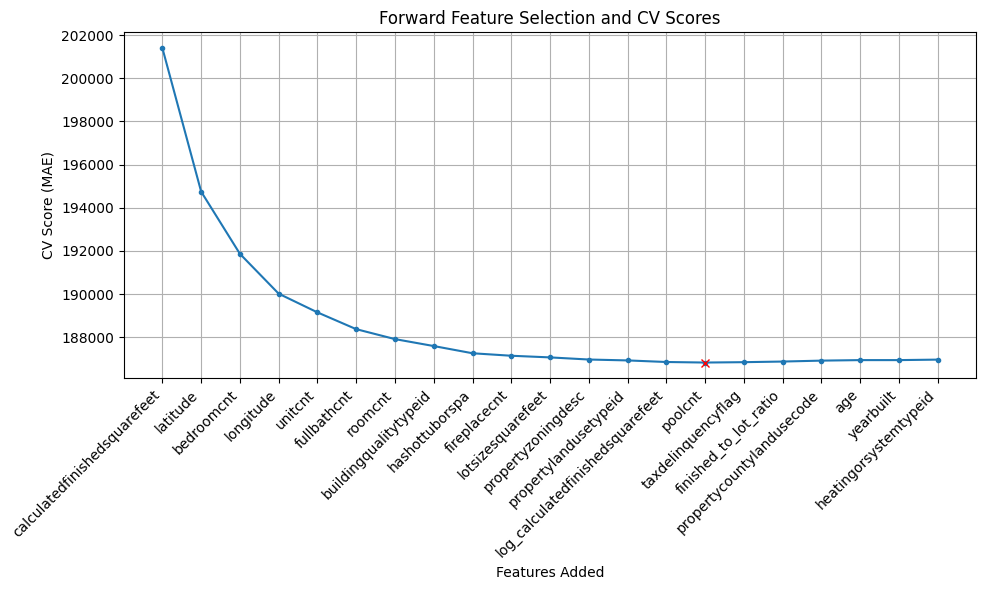

Best Features: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt', 'fullbathcnt', 'roomcnt', 'buildingqualitytypeid', 'hashottuborspa', 'fireplacecnt', 'lotsizesquarefeet', 'propertyzoningdesc', 'propertylandusetypeid', 'log_calculatedfinishedsquarefeet', 'poolcnt']
Best CV Score: 186824.2522


In [37]:
# Create dataframe of X_train_scaled to maintain feature names during feature selection
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns,index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled,columns=X_test.columns,index=X_test.index)

# Run forward feature selection using linear regression model
selected_features, best_scores, best_linear_features, best_score =    (
            forward_feature_selection(X_train_scaled_df, y_train, model=LinearRegression(),
                                       scoring="neg_mean_absolute_error", verbose=True))


# Plot the results
index = np.argmax(np.array(selected_features) == best_linear_features[-1])

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(best_scores) + 1), best_scores, marker='.')
plt.plot([index+1],best_score,marker='x',color='red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation=45, ha='right')
plt.title('Forward Feature Selection and CV Scores')
plt.xlabel('Features Added')
plt.ylabel('CV Score (MAE)')
plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and score
print(f"Best Features: {best_linear_features}")
print(f"Best CV Score: {best_score:.4f}")

In [ ]:
# Run linear regression model on best feature subset
X_train_best_linear = X_train_scaled_df[best_linear_features]
X_test_best_linear = X_test_scaled_df[best_linear_features]

# Run the test set through the model
mean_cv_mae_linear_feat, std_cv_mae_linear_feat, lr_model_feat = run_linear_regression(X_train_best_linear, y_train, 
                                                                        X_test_best_linear, y_test)

#Printing the results
print("Linear Regression:\n")
print(f"Mean CV MAE: {mean_cv_mae_linear_feat:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_linear_feat:.4f}")
print(f"Best Linear Feature Subset: {best_linear_features}")

Linear Regression:

Mean CV MAE: 186798.7427
Standard Deviation of CV MAE: 1189.5640

Best Linear Feature Subset: ['calculatedfinishedsquarefeet', 'latitude', 'bedroomcnt', 'longitude', 'unitcnt', 'fullbathcnt', 'roomcnt', 'buildingqualitytypeid', 'hashottuborspa', 'fireplacecnt', 'lotsizesquarefeet', 'propertyzoningdesc', 'propertylandusetypeid', 'log_calculatedfinishedsquarefeet', 'poolcnt']


In [ ]:
# Identify most importance features of decision tree model using built in feature importance 
dt_importances = dt_model_new.feature_importances_

# Sort features by importance
dt_feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': dt_importances}).sort_values(
    'Importance', ascending=False)

dt_feature_importances_df

,Feature,Importance
7,latitude,0.173721
18,log_calculatedfinishedsquarefeet,0.154063
8,longitude,0.130093
2,calculatedfinishedsquarefeet,0.115759
20,finished_to_lot_ratio,0.080232
9,lotsizesquarefeet,0.069309
16,yearbuilt,0.055871
19,age,0.048648
13,propertyzoningdesc,0.038241
1,buildingqualitytypeid,0.035273


In [81]:
# Run decision tree models over subsets of sorted features 
dt_results = []
subset_sizes = [8, 12, 14, 18]

for i in subset_sizes:
    
    # Select top-i feature subset
    selected_features = dt_feature_importances_df["Feature"].head(i)
    X_subset = X_train_scaled_df[selected_features] 
    
    # Run decision tree model using smaller hyperparameters for performance
    mean_mae, std_mae, _ = run_decision_tree_regressor(X_subset, y_train, max_depth=4)
    
    dt_results.append({
        "num_features": i,
        "mean_cv_mae": mean_mae,
        "std_cv_mae": std_mae
    })

# Sort results of decision tree feature selection by mean_cv_mae
sorted(dt_results, key=lambda x: x["mean_cv_mae"])

[{'num_features': 18,
  'mean_cv_mae': np.float64(189627.2435828896),
  'std_cv_mae': np.float64(1594.0910330647023)},
 {'num_features': 14,
  'mean_cv_mae': np.float64(189628.40547179684),
  'std_cv_mae': np.float64(1593.4209527531848)},
 {'num_features': 12,
  'mean_cv_mae': np.float64(189629.09279727284),
  'std_cv_mae': np.float64(1594.7289897423984)},
 {'num_features': 8,
  'mean_cv_mae': np.float64(190270.06123812462),
  'std_cv_mae': np.float64(1619.2802873648475)}]

In [91]:
# Run decision model with selected subset of features at baseline hyperparamters
best_dt_features = dt_feature_importances_df["Feature"].head(18)

mean_cv_mae_dt_feat, std_cv_mae_dt_feat, dt_model_feat = run_decision_tree_regressor(X_train_scaled_df[best_dt_features] , y_train)

#Printing the results
print("Decision Tree:\n")
print(f"Mean CV MAE: {mean_cv_mae_dt_new:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_dt_new:.4f}")
print(f"Best DT Feature Subset: {best_dt_features}")

Decision Tree:

Mean CV MAE: 215606.7445
Standard Deviation of CV MAE: 2171.4746
Best DT Feature Subset: 7                             latitude
18    log_calculatedfinishedsquarefeet
8                            longitude
2         calculatedfinishedsquarefeet
20               finished_to_lot_ratio
9                    lotsizesquarefeet
16                           yearbuilt
19                                 age
13                  propertyzoningdesc
1                buildingqualitytypeid
0                           bedroomcnt
4                          fullbathcnt
11           propertycountylandusecode
14                             roomcnt
10                             poolcnt
6                heatingorsystemtypeid
3                         fireplacecnt
17                  taxdelinquencyflag
Name: Feature, dtype: object


In [ ]:
# Identify most importance features of decision tree model using built in feature importance 
rf_importances = rf_model_new.feature_importances_

# Sort features by importance
rf_feature_importances_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf_importances}).sort_values(
    'Importance', ascending=False)

rf_feature_importances_df


,Feature,Importance
2,calculatedfinishedsquarefeet,0.207490
18,log_calculatedfinishedsquarefeet,0.192777
7,latitude,0.163629
8,longitude,0.106367
1,buildingqualitytypeid,0.054318
20,finished_to_lot_ratio,0.048217
9,lotsizesquarefeet,0.046257
19,age,0.042838
16,yearbuilt,0.041328
13,propertyzoningdesc,0.025636


In [ ]:
rf_results = []
subset_sizes = [6, 8, 10, 12, 14, 16, 18, 20]

for i in subset_sizes:
    
    # Select top-i feature subset
    selected_features = rf_feature_importances_df["Feature"].head(i)
    X_subset = X_train_scaled_df[selected_features] 
    
    # Run random forest model using smaller hyperparameters for performance
    mean_mae, std_mae, _ = run_random_forest_regressor(X_subset, y_train, n_estimators=50, max_depth=10)
    
    rf_results.append({
        "num_features": i,
        "mean_cv_mae": mean_mae,
        "std_cv_mae": std_mae
    })

sorted(rf_results, key=lambda x: x["mean_cv_mae"])

[{'num_features': 6,
  'mean_cv_mae': np.float64(169003.67907389876),
  'std_cv_mae': np.float64(1354.7080613753108)},
 {'num_features': 12,
  'mean_cv_mae': np.float64(166394.31478725324),
  'std_cv_mae': np.float64(1409.3668947886008)},
 {'num_features': 10,
  'mean_cv_mae': np.float64(166285.50111021736),
  'std_cv_mae': np.float64(1399.1872095076415)},
 {'num_features': 16,
  'mean_cv_mae': np.float64(166270.74572737576),
  'std_cv_mae': np.float64(1406.2850348369325)},
 {'num_features': 14,
  'mean_cv_mae': np.float64(166259.5216723316),
  'std_cv_mae': np.float64(1409.1444169913336)},
 {'num_features': 20,
  'mean_cv_mae': np.float64(166234.60357518838),
  'std_cv_mae': np.float64(1411.3535562992924)},
 {'num_features': 18,
  'mean_cv_mae': np.float64(166214.64377240496),
  'std_cv_mae': np.float64(1412.7115232823674)},
 {'num_features': 8,
  'mean_cv_mae': np.float64(166189.7964628606),
  'std_cv_mae': np.float64(1380.8876747167378)}]

In [ ]:
# Run random forest model with selected subset of features at baseline hyperparamters
best_rf_features = rf_feature_importances_df["Feature"].head(8)

mean_cv_mae_rf_feat, std_cv_mae_rf_feat, rf_model_feat = run_random_forest_regressor(X_train_scaled_df[best_rf_features], y_train, 
                                n_estimators = 100,       
                                max_depth = None,         
                                min_samples_split = 2,    
                                min_samples_leaf = 1,     
                                max_samples = None,       
                                max_leaf_nodes=None,
                                max_features = 1.0,             
                                ccp_alpha=0.0)

#Printing the results
print("Random Forest:\n")
print(f"Mean CV MAE: {mean_cv_mae_rf_feat:.4f}")
print(f"Standard Deviation of CV MAE: {std_cv_mae_rf_feat:.4f}")
print(f"Best RF Feature Subset: {best_rf_features}")

Random Forest:

Mean CV MAE: 162350.6939
Standard Deviation of CV MAE: 1501.7658
Best RF Feature Subset: 2         calculatedfinishedsquarefeet
18    log_calculatedfinishedsquarefeet
7                             latitude
8                            longitude
1                buildingqualitytypeid
20               finished_to_lot_ratio
9                    lotsizesquarefeet
19                                 age
Name: Feature, dtype: object


### Part 3: Discussion [3 pts]

Analyze the effect of feature selection on your models:

- Did performance improve for any models after reducing the number of features?

- Which features were consistently retained across models?

- Were any of your newly engineered features selected as important?


> Your text here

### Part 4: Fine-Tuning Your Three Models [6 pts]

In this final phase of Milestone 2, you’ll select and refine your **three most promising models and their corresponding data pipelines** based on everything you've done so far, and pick a winner!

1. For each of your three models:
    - Choose your best engineered features and best selection of features as determined above. 
   - Perform hyperparameter tuning using `sweep_parameters`, `GridSearchCV`, `RandomizedSearchCV`, `Optuna`, etc. as you have practiced in previous homeworks. 
3. Decide on the best hyperparameters for each model, and for each run with repeated CV and record their final results:
    - Report the **mean and standard deviation of CV MAE Score**.  

In [21]:
# Add as many cells as you need


### Part 4: Discussion [3 pts]

Reflect on your tuning process and final results:

- What was your tuning strategy for each model? Why did you choose those hyperparameters?
- Did you find that certain types of preprocessing or feature engineering worked better with specific models?


> Your text here

### Part 5: Final Model and Design Reassessment [6 pts]

In this part, you will finalize your best-performing model.  You’ll also consolidate and present the key code used to run your model on the preprocessed dataset.
**Requirements:**

- Decide one your final model among the three contestants. 

- Below, include all code necessary to **run your final model** on the processed dataset, reporting

    - Mean and standard deviation of CV MAE Score.
    
    - Test score on held-out test set. 




In [22]:
# Add as many cells as you need


### Part 5: Discussion [8 pts]

In this final step, your goal is to synthesize your entire modeling process and assess how your earlier decisions influenced the outcome. Please address the following:

1. Model Selection:
- Clearly state which model you selected as your final model and why.

- What metrics or observations led you to this decision?

- Were there trade-offs (e.g., interpretability vs. performance) that influenced your choice?

2. Revisiting an Early Decision

- Identify one specific preprocessing or feature engineering decision from Milestone 1 (e.g., how you handled missing values, how you scaled or encoded a variable, or whether you created interaction or polynomial terms).

- Explain the rationale for that decision at the time: What were you hoping it would achieve?

- Now that you've seen the full modeling pipeline and final results, reflect on whether this step helped or hindered performance. Did you keep it, modify it, or remove it?

- Justify your final decision with evidence—such as validation scores, visualizations, or model diagnostics.

3. Lessons Learned

- What insights did you gain about your dataset or your modeling process through this end-to-end workflow?

- If you had more time or data, what would you explore next?

> Your text here